In [ ]:
import shutil

In [ ]:
! pip install mace-torch

In [ ]:
! pip install pymbar

In [ ]:
from google.colab import drive # mount drive for easier import/ export
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! ls "/content/drive/MyDrive/3.POD"

0.Input    2.NVT_450  4.NVT_800  6.NPT_450  8.NPT_800
1.NVT_300  3.NVT_600  5.NPT_300  7.NPT_600


In [ ]:
import sys
import os
from mace.cli.run_train import main

/usr/local/lib/python3.13/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
# import ipywidgets as widgets
# from IPython.display import display
# import io

# uploader = widgets.FileUpload(multiple=True)
# display(uploader)

In [ ]:
# for filename, file_info in uploader.value.items():
#     print(f"Uploading {filename}...")
#     content = file_info['content']
#     with open(filename, 'wb') as f:
#         f.write(content)
# print("All done")

In [ ]:
import importlib
import useful_functions_new
importlib.reload(useful_functions_new)
from useful_functions_new import clean_dataset, load_trajectories, read_merged, check_convergence, tail_band_t0 # custom functions for easier re-runs

In [ ]:
par_dir="/content/drive/MyDrive/3.POD"

import glob

outcar_paths = sorted(glob.glob(f"{par_dir}/**/OUTCAR", recursive=True))

# upon inspection, these proved to be bad simulations:
bad_outcar_paths=["/content/drive/MyDrive/3.POD/0.Input/Gam_MD/ONe/OUTCAR",
                  "/content/drive/MyDrive/3.POD/0.Input/Gam_MD/OUTCAR",
                  '/content/drive/MyDrive/3.POD/0.Input/Gam_MD/Tree/OUTCAR',
                  '/content/drive/MyDrive/3.POD/0.Input/OUTCAR'
                  ]

outcar_paths=[p for p in outcar_paths if p not in bad_outcar_paths]

In [ ]:
outcar_paths

['/content/drive/MyDrive/3.POD/1.NVT_300/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/1.NVT_300/B.10K1_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/1.NVT_300/C.2473_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/2.NVT_450/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/2.NVT_450/B.10K1_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/2.NVT_450/C.2594_30K/OUTCAR',
 '/content/drive/MyDrive/3.POD/3.NVT_600/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/3.NVT_600/B.10K1_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/3.NVT_600/C.2650_30K/OUTCAR',
 '/content/drive/MyDrive/3.POD/4.NVT_800/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/4.NVT_800/B.10K1_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/4.NVT_800/C.2505_30K/OUTCAR',
 '/content/drive/MyDrive/3.POD/5.NPT_300/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/5.NPT_300/B.10K1_20K/OUTCAR',
 '/content/drive/MyDrive/3.POD/5.NPT_300/C.2390_30K/OUTCAR',
 '/content/drive/MyDrive/3.POD/6.NPT_450/A.1_10K/OUTCAR',
 '/content/drive/MyDrive/3.POD/6.NPT_450/B

In [ ]:
runs = {
    "NVT_300": outcar_paths[0:3],
    "NVT_450": outcar_paths[3:6],
    "NVT_600": outcar_paths[6:9],
    "NVT_800": outcar_paths[9:12],
    "NPT_300": outcar_paths[12:15],
    "NPT_450": outcar_paths[15:18],
    "NPT_600": outcar_paths[18:21],
    "NPT_800": outcar_paths[21:24],
}


In [ ]:
# use this simpler approach also to make more informed decision about convergence:

In [ ]:
import pickle
import numpy as np

save_dir="/content/drive/MyDrive/datasets_for_mace/convergence_check/"



for key in runs.keys():
    path=save_dir + f"/convergence_{key}.pickle"

    for tail_frac in list(np.arange(0.1,1.,0.1)):
      with open(path, "rb") as f:
          m = pickle.load(f)

      ws = m["window_size"]
      #n = len(m["temperatures"])

      t0 = {
          "temperature": tail_band_t0(m["temperatures"], tail_frac, window=50),
          "g_max": tail_band_t0(m["g_max_history"], tail_frac, window=5) * ws,
      }
      if m["energies"] is not None:
          t0["energy"] = tail_band_t0(m["energies"], tail_frac, window=50)

      consensus = max(t0.values())
      #unconverged = consensus >= (1 - tail_frac) * n

      print(m["label"], t0, "consensus:", consensus)#, "UNCONVERGED" if unconverged else "")
    print("=========================================================================================================================")

NVT_300 {'temperature': np.int64(15216), 'g_max': np.int64(18560), 'energy': np.int64(17641)} consensus: 18560
NVT_300 {'temperature': np.int64(15217), 'g_max': np.int64(14440), 'energy': np.int64(16973)} consensus: 16973
NVT_300 {'temperature': np.int64(15204), 'g_max': np.int64(14400), 'energy': np.int64(16972)} consensus: 16972
NVT_300 {'temperature': np.int64(14722), 'g_max': np.int64(13280), 'energy': np.int64(5875)} consensus: 14722
NVT_300 {'temperature': np.int64(8499), 'g_max': np.int64(9480), 'energy': np.int64(5863)} consensus: 9480
NVT_300 {'temperature': np.int64(7369), 'g_max': np.int64(8380), 'energy': np.int64(5857)} consensus: 8380
NVT_300 {'temperature': np.int64(6170), 'g_max': np.int64(6640), 'energy': np.int64(5853)} consensus: 6640
NVT_300 {'temperature': np.int64(6164), 'g_max': np.int64(4520), 'energy': np.int64(5843)} consensus: 6164
NVT_300 {'temperature': np.int64(6158), 'g_max': np.int64(2380), 'energy': np.int64(5835)} consensus: 6158
NVT_450 {'temperature'

In [ ]:
# # debugging
# import numpy as np
# from ase.io import read
# from ase.geometry import find_mic

# def junction(path_a, path_b, dt=0.5):
#     print(f"Checking {path_a} and follwing...")
#     a_last = read(path_a, index=-1)
#     a_prev = read(path_a, index=-2)
#     b_first = read(path_b, index=0)

#     step_a = find_mic(a_last.positions - a_prev.positions,
#                       a_last.cell, pbc=a_last.pbc)[0]
#     jump = find_mic(b_first.positions - a_last.positions,
#                     a_last.cell, pbc=a_last.pbc)[0]


#     print("n atoms:", len(a_last), len(b_first))
#     print("typical step in A (rms, A):", np.sqrt((step_a**2).sum(1).mean()))
#     print("jump A_last -> B_first (rms, A):", np.sqrt((jump**2).sum(1).mean()))
#     print("E last A:", a_last.get_potential_energy(),
#           "E first B:", b_first.get_potential_energy())
#     print("cell A_last vs B_first:\n", a_last.cell.array, "\n", b_first.cell.array)
#     print("="*20)
# for i in range(0,len(outcar_paths)):
#   if ((i+1)%3 == 0): pass
#   else:
#     pa=outcar_paths[i]
#     pb=outcar_paths[i+1]
#     junction(pa,pb)


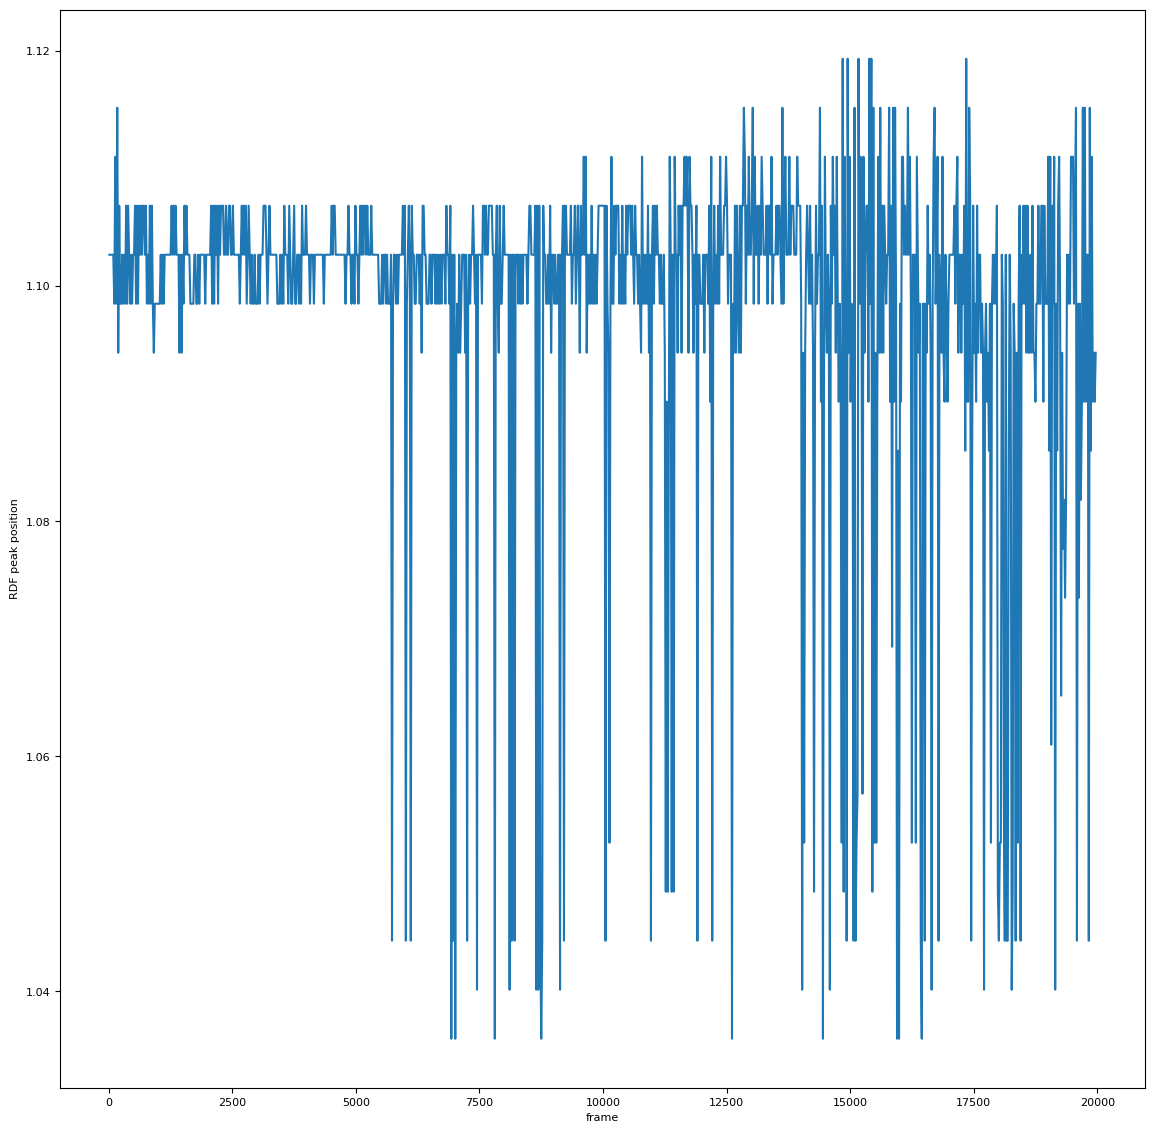

In [ ]:
# more debugging:
# reason why we dropped FWHM as convergence metric is that at some point argmax of RDF starts jumping - but for the same reason we also keep gmax (unaffected)
peak_r_history = []
time_steps = []

frames=read_merged(outcar_paths[0:3])
window_size=20
rmax=4.1689
nbins=1000

from ase.geometry.rdf import get_rdf

for start_idx in range(0, len(frames) - window_size + 1, window_size):
    window_rdfs = []
    for atoms in frames[start_idx : start_idx + window_size]:
        rdf_vals, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
        window_rdfs.append(rdf_vals)
    window_avg_rdf = np.mean(window_rdfs, axis=0)

    max_idx = np.argmax(window_avg_rdf)
    peak_r_history.append(distances[max_idx])
    time_steps.append(start_idx + window_size // 2)

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 14))
plt.plot(time_steps, peak_r_history,)
plt.xlabel("frame")
plt.ylabel("RDF peak position")
plt.show()

Merged ['/content/drive/MyDrive/3.POD/1.NVT_300/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/1.NVT_300/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/1.NVT_300/C.2473_20K/OUTCAR']


****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



Auto-selected rmax = 4.169 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NVT_300.pickle
Saved convergence plot to ./convergence_check/convergence_NVT_300.png


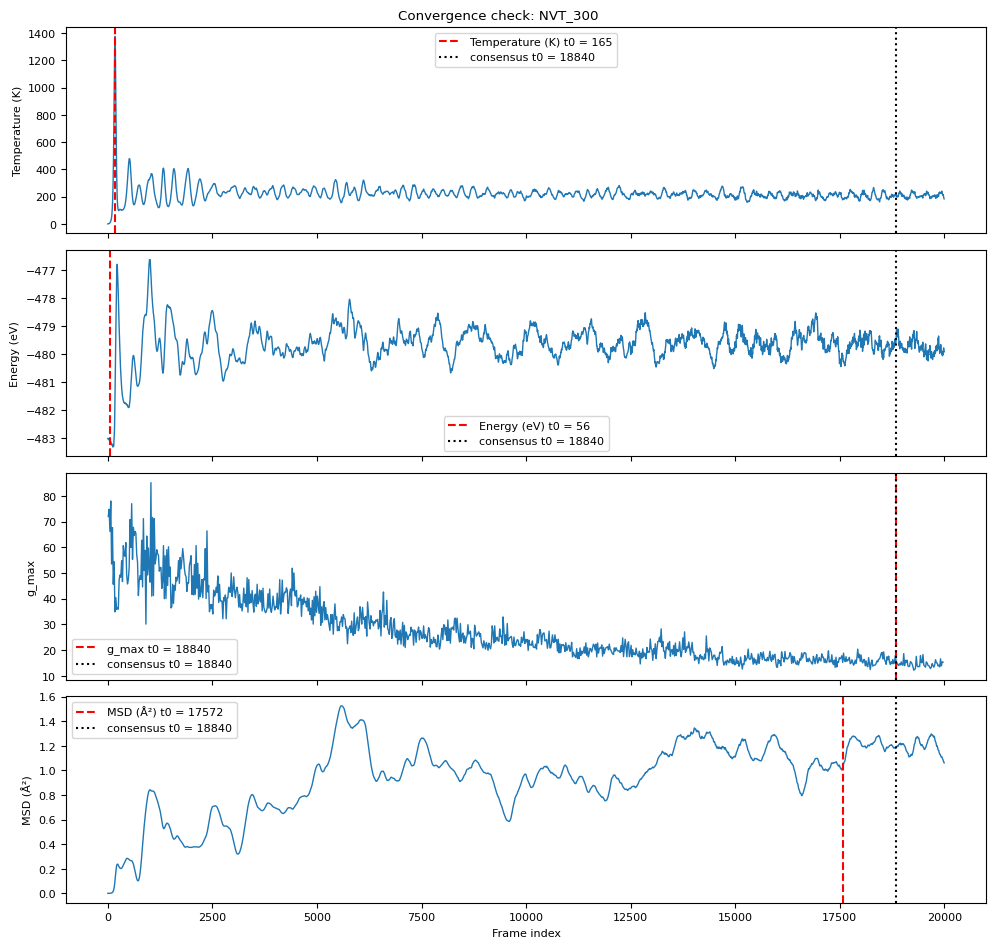

NVT_300 t0_consensus = 18840
NVT_300 t0_per_metric = {'temperature': np.int64(165), 'g_max': np.int64(18840), 'msd': np.int64(17572), 'energy': np.int64(56)}
NVT_300 g_per_metric  = {'temperature': np.float32(69.07019), 'g_max': np.float32(1.1838791), 'msd': np.float32(141.15324), 'energy': np.float32(205.12947)}
Merged ['/content/drive/MyDrive/3.POD/2.NVT_450/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/2.NVT_450/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/2.NVT_450/C.2594_30K/OUTCAR']
Auto-selected rmax = 4.169 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NVT_450.pickle
Saved convergence plot to ./convergence_check/convergence_NVT_450.png


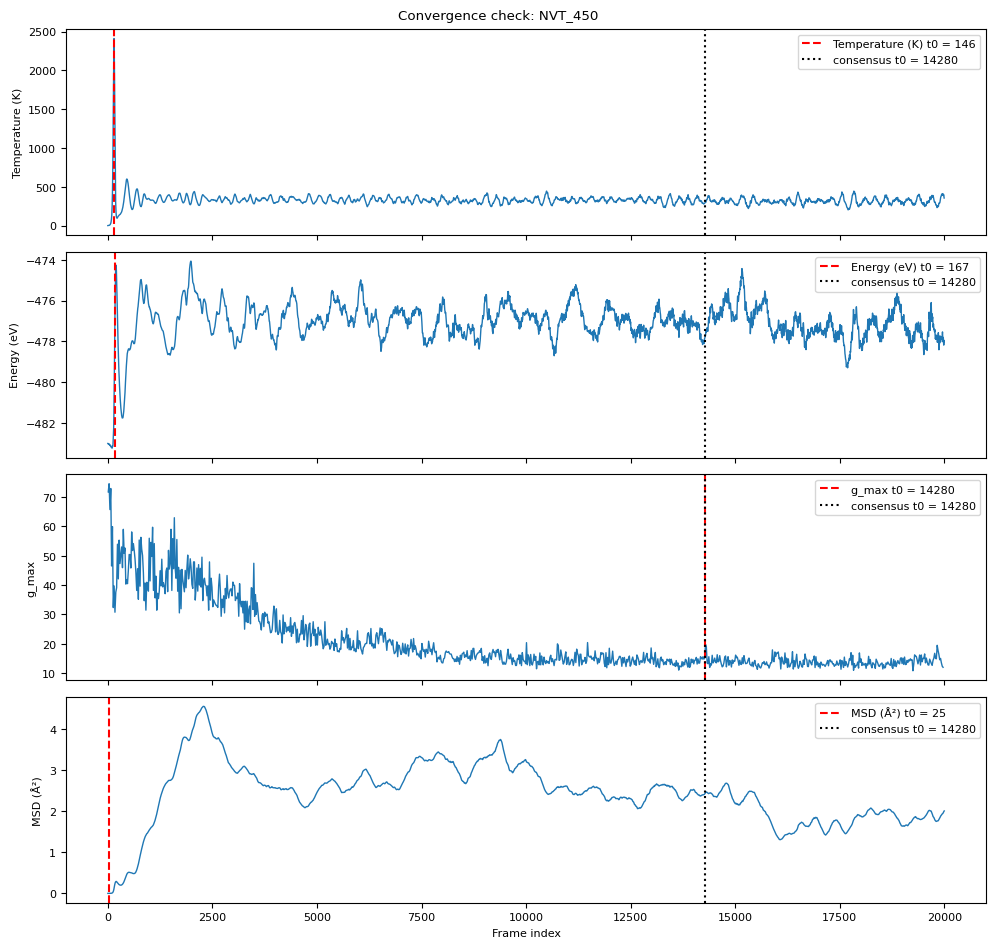

NVT_450 t0_consensus = 14280
NVT_450 t0_per_metric = {'temperature': np.int64(146), 'g_max': np.int64(14280), 'msd': np.int64(25), 'energy': np.int64(167)}
NVT_450 g_per_metric  = {'temperature': np.float32(47.875114), 'g_max': np.float32(3.1864793), 'msd': np.float32(1546.5435), 'energy': np.float32(254.67026)}
Merged ['/content/drive/MyDrive/3.POD/3.NVT_600/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/3.NVT_600/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/3.NVT_600/C.2650_30K/OUTCAR']
Auto-selected rmax = 4.169 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NVT_600.pickle
Saved convergence plot to ./convergence_check/convergence_NVT_600.png


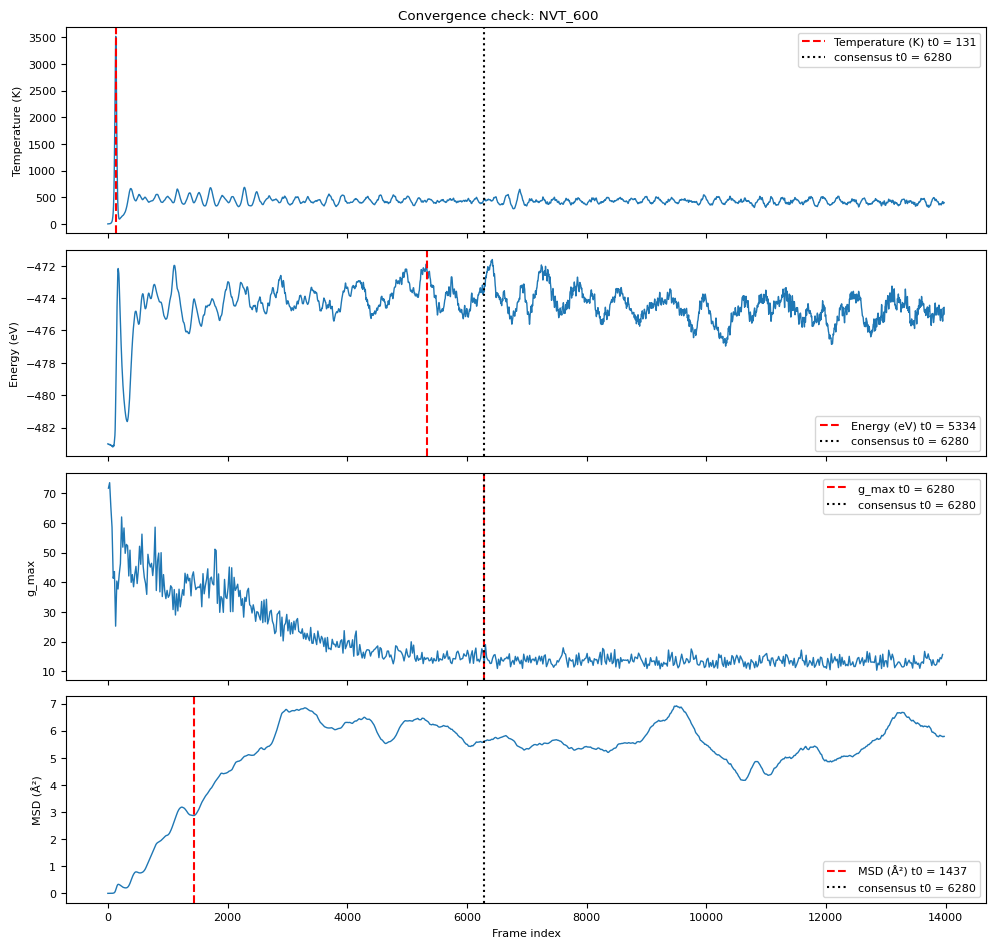

NVT_600 t0_consensus = 6280
NVT_600 t0_per_metric = {'temperature': np.int64(131), 'g_max': np.int64(6280), 'msd': np.int64(1437), 'energy': np.int64(5334)}
NVT_600 g_per_metric  = {'temperature': np.float32(38.42319), 'g_max': np.float32(1.6918874), 'msd': np.float32(969.92926), 'energy': np.float32(251.33661)}
Merged ['/content/drive/MyDrive/3.POD/4.NVT_800/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/4.NVT_800/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/4.NVT_800/C.2505_30K/OUTCAR']
Auto-selected rmax = 4.169 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NVT_800.pickle
Saved convergence plot to ./convergence_check/convergence_NVT_800.png


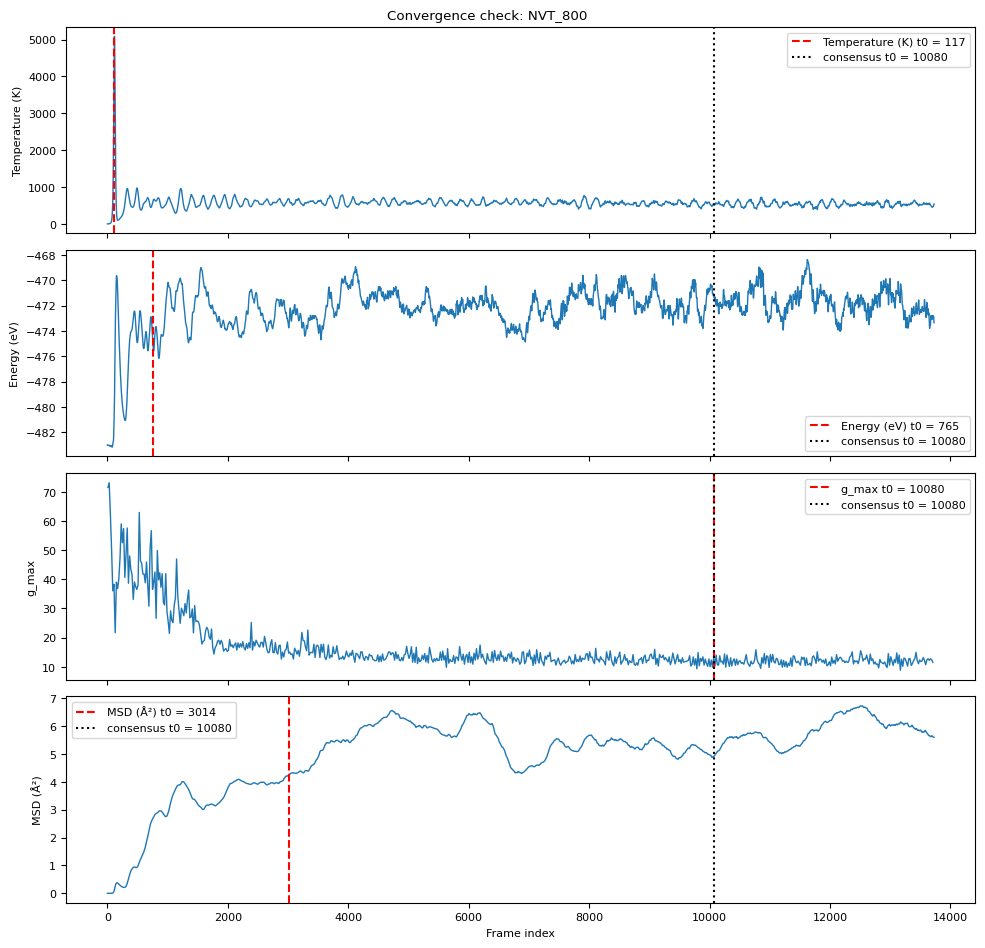

NVT_800 t0_consensus = 10080
NVT_800 t0_per_metric = {'temperature': np.int64(117), 'g_max': np.int64(10080), 'msd': np.int64(3014), 'energy': np.int64(765)}
NVT_800 g_per_metric  = {'temperature': np.float32(34.52042), 'g_max': np.float32(1.3593575), 'msd': np.float32(899.84546), 'energy': np.float32(224.77063)}
Merged ['/content/drive/MyDrive/3.POD/5.NPT_300/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/5.NPT_300/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/5.NPT_300/C.2390_30K/OUTCAR']
Auto-selected rmax = 3.808 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NPT_300.pickle
Saved convergence plot to ./convergence_check/convergence_NPT_300.png


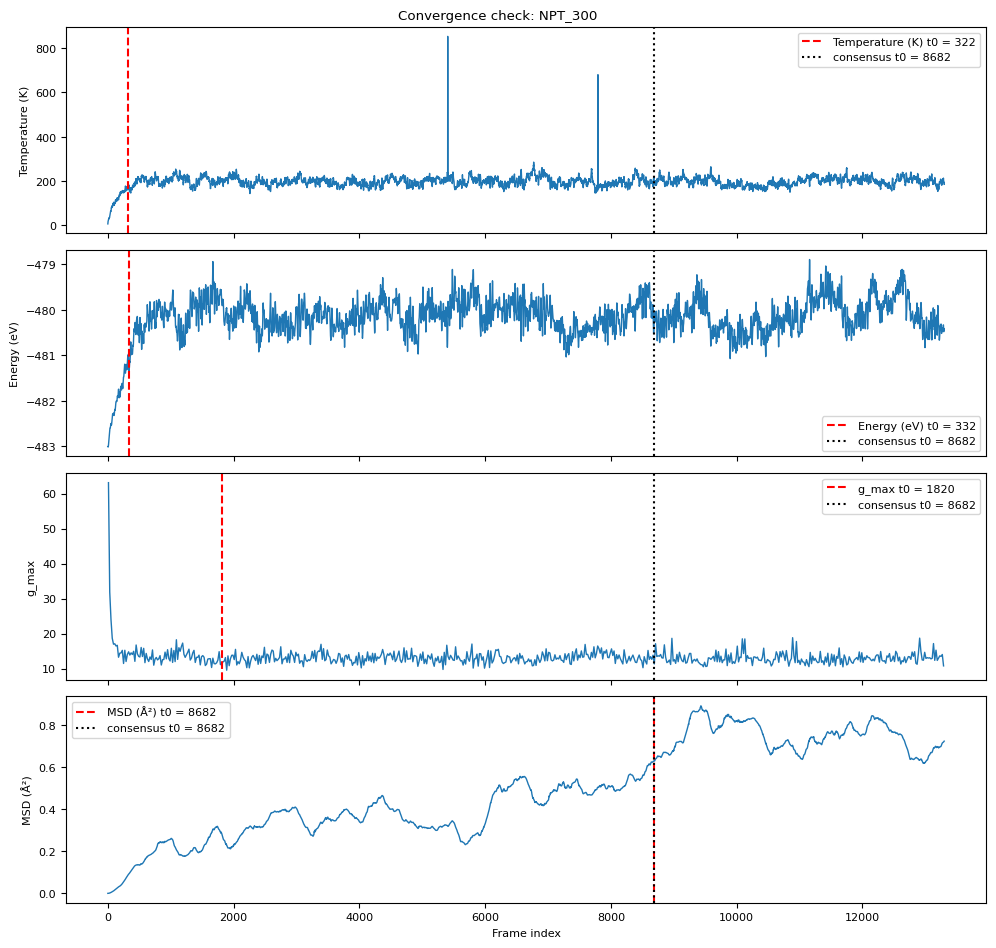

NPT_300 t0_consensus = 8682
NPT_300 t0_per_metric = {'temperature': np.int64(322), 'g_max': np.int64(1820), 'msd': np.int64(8682), 'energy': np.int64(332)}
NPT_300 g_per_metric  = {'temperature': np.float32(100.02634), 'g_max': np.float32(2.895724), 'msd': np.float32(493.12634), 'energy': np.float32(251.19112)}
Merged ['/content/drive/MyDrive/3.POD/6.NPT_450/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/6.NPT_450/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/6.NPT_450/C.2352_30K/OUTCAR']
Auto-selected rmax = 3.876 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NPT_450.pickle
Saved convergence plot to ./convergence_check/convergence_NPT_450.png


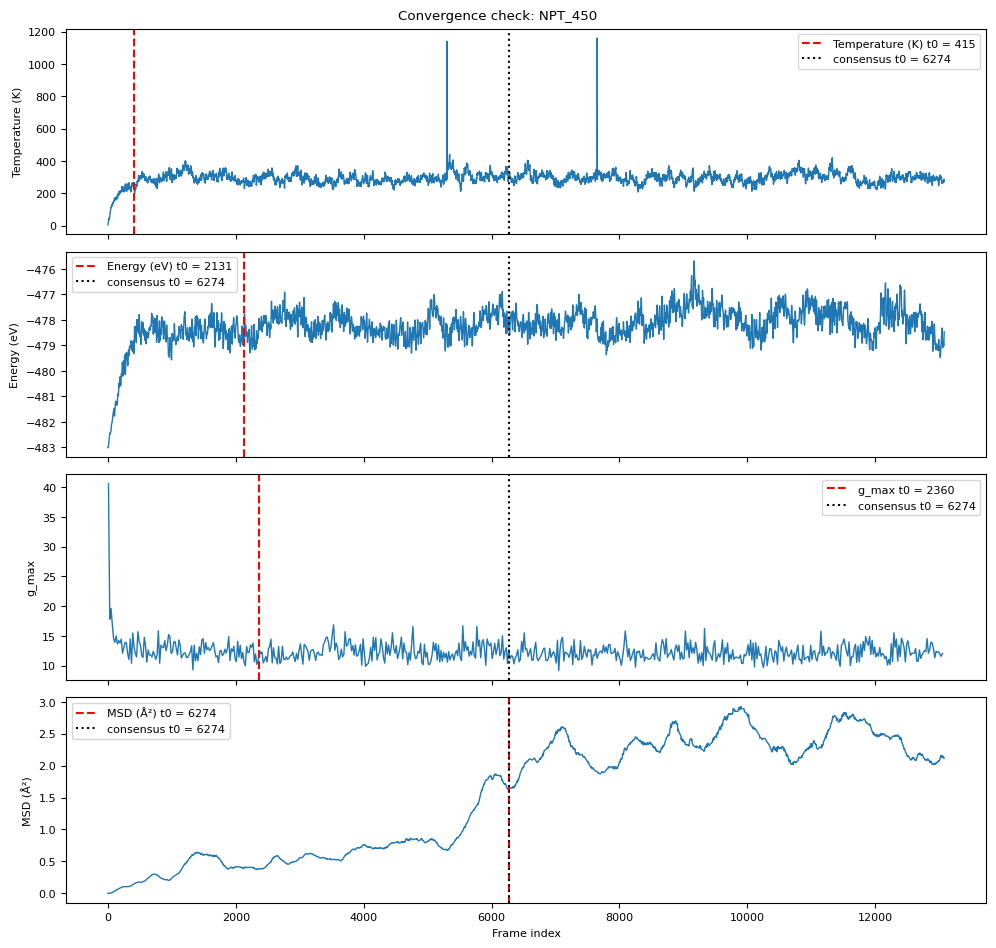

NPT_450 t0_consensus = 6274
NPT_450 t0_per_metric = {'temperature': np.int64(415), 'g_max': np.int64(2360), 'msd': np.int64(6274), 'energy': np.int64(2131)}
NPT_450 g_per_metric  = {'temperature': np.float32(137.27554), 'g_max': np.float32(2.509484), 'msd': np.float32(556.97986), 'energy': np.float32(252.4352)}
Merged ['/content/drive/MyDrive/3.POD/7.NPT_600/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/7.NPT_600/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/7.NPT_600/C.2420_30K/OUTCAR']
Auto-selected rmax = 3.887 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NPT_600.pickle
Saved convergence plot to ./convergence_check/convergence_NPT_600.png


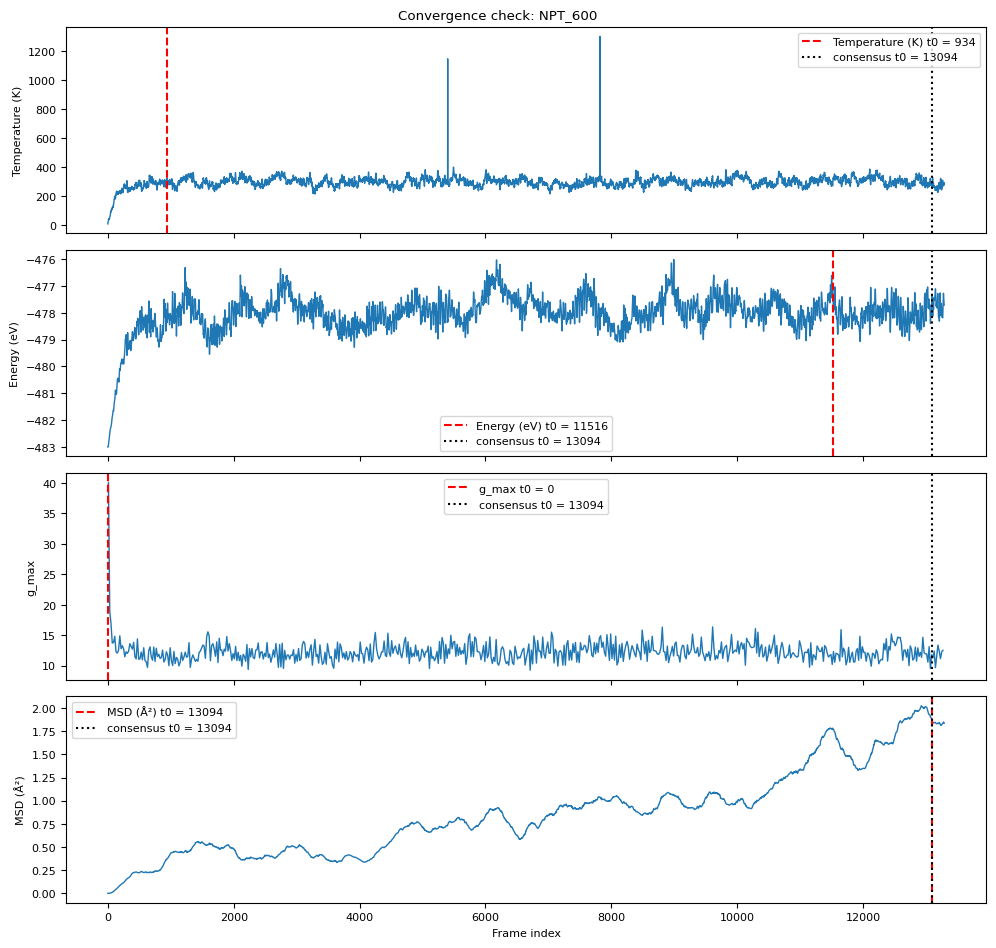

NPT_600 t0_consensus = 13094
NPT_600 t0_per_metric = {'temperature': np.int64(934), 'g_max': np.int64(0), 'msd': np.int64(13094), 'energy': np.int64(11516)}
NPT_600 g_per_metric  = {'temperature': np.float32(79.964165), 'g_max': np.float32(4.0291767), 'msd': np.float32(26.85737), 'energy': np.float32(18.788782)}
Merged ['/content/drive/MyDrive/3.POD/8.NPT_800/A.1_10K/OUTCAR', '/content/drive/MyDrive/3.POD/8.NPT_800/B.10K1_20K/OUTCAR', '/content/drive/MyDrive/3.POD/8.NPT_800/C.2095_30K/OUTCAR']
Auto-selected rmax = 3.854 Å (smallest cell over full trajectory)
Saved convergence metrics to ./convergence_check/convergence_NPT_800.pickle
Saved convergence plot to ./convergence_check/convergence_NPT_800.png


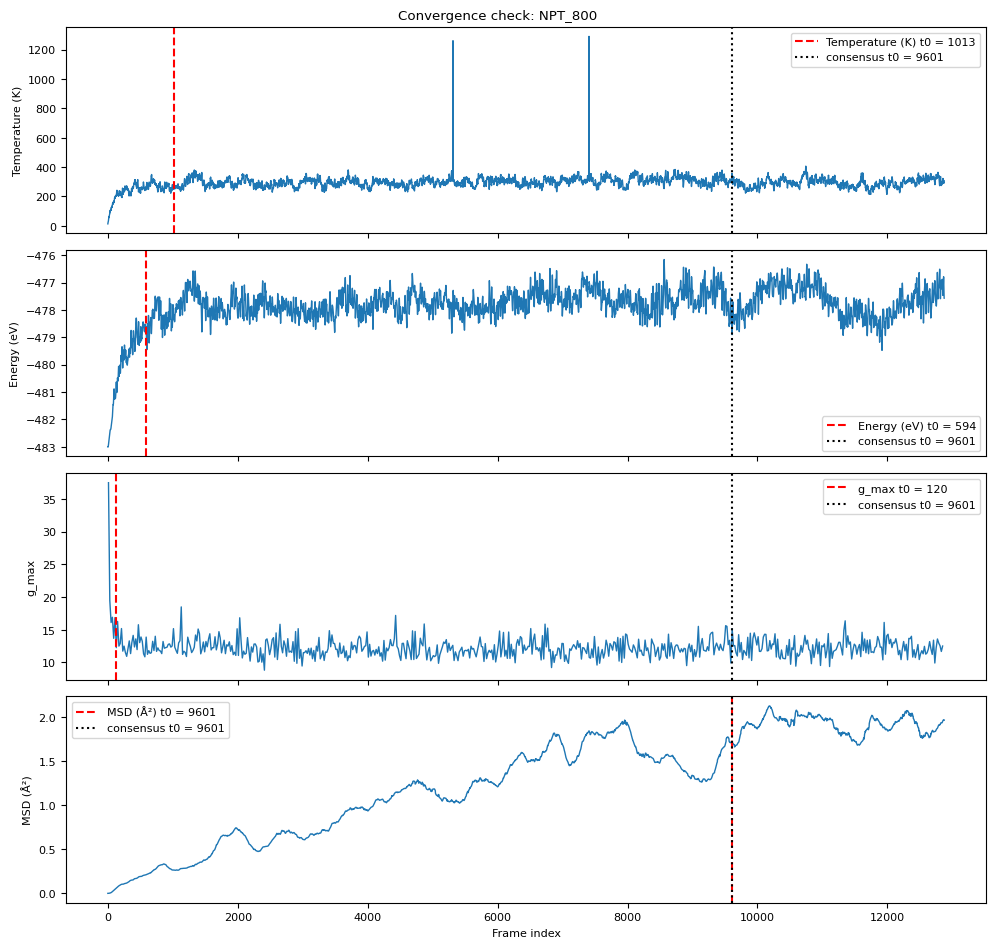

NPT_800 t0_consensus = 9601
NPT_800 t0_per_metric = {'temperature': np.int64(1013), 'g_max': np.int64(120), 'msd': np.int64(9601), 'energy': np.int64(594)}
NPT_800 g_per_metric  = {'temperature': np.float32(97.94246), 'g_max': np.float32(2.7823281), 'msd': np.float32(266.7804), 'energy': np.float32(290.6165)}


In [ ]:
# took 58 minutes (CPU)


for name, paths in runs.items():
    frames = read_merged(paths)
    print(f"Merged {paths}")
    t0, t0_per_metric, g_per_metric = check_convergence(
        frames,
        plot=True,
        label=name,
        save_dir="./convergence_check",
    )
    print(name, "t0_consensus =", t0)
    print(name, "t0_per_metric =", t0_per_metric)
    print(name, "g_per_metric  =", g_per_metric)

In [ ]:
# print results
import pickle, glob, os

for path in sorted(glob.glob("./convergence_check/convergence_*.pickle")):
    with open(path, "rb") as f:
        m = pickle.load(f)
    label = m["label"]
    print(f"\n=== {label} ===")
    # print(f"  rmax            = {m['rmax']:.3f} Å")
    # print(f"  window_size     = {m['window_size']}")
    # print(f"  t0_consensus    = {m['t0_consensus']}")
    print("  t0 per metric:")
    for k, v in m["t0_per_metric"].items():
      print(f"      {k:<12} t0 = {v}")

    print("  g (statistical inefficiency, in frames):")
    for k, v in m["g_per_metric"].items():
        print(f"      {k:<12} g  = {v:.3f}")
    # print("  Neff:")
    # for k, v in m["Neff_per_metric"].items():
    #     print(f"      {k:<12} Neff = {v:.2f}")


=== NPT_300 ===
  g (statistical inefficiency, in frames):
      temperature  g  = 100.026
      g_max        g  = 2.896
      msd          g  = 493.126
      energy       g  = 251.191

=== NPT_450 ===
  g (statistical inefficiency, in frames):
      temperature  g  = 137.276
      g_max        g  = 2.509
      msd          g  = 556.980
      energy       g  = 252.435

=== NPT_600 ===
  g (statistical inefficiency, in frames):
      temperature  g  = 79.964
      g_max        g  = 4.029
      msd          g  = 26.857
      energy       g  = 18.789

=== NPT_800 ===
  g (statistical inefficiency, in frames):
      temperature  g  = 97.942
      g_max        g  = 2.782
      msd          g  = 266.780
      energy       g  = 290.616

=== NVT_300 ===
  g (statistical inefficiency, in frames):
      temperature  g  = 69.070
      g_max        g  = 1.184
      msd          g  = 141.153
      energy       g  = 205.129

=== NVT_450 ===
  g (statistical inefficiency, in frames):
      temperatu

In [ ]:
conv_frames=[14722, 14280, 6926, 5000,
             8682, 6274, 6238, 2000] # 4th and 8th manual

buffers=[206,255,252,225,252,253,300,291] # msd left out, energy more or less consistent

In [ ]:
frames_nvt_300=read_merged(outcar_paths[0:3])

len(frames_nvt_300)

19998

traj_0: read 19998 frames
traj_0: using fixed start frame 14722
traj_0: t0=14722, test=900, buffer=1236, train candidates=1786
Total training-pool frames from all files (before FPS, if any): 1786
Total test frames from all files: 900


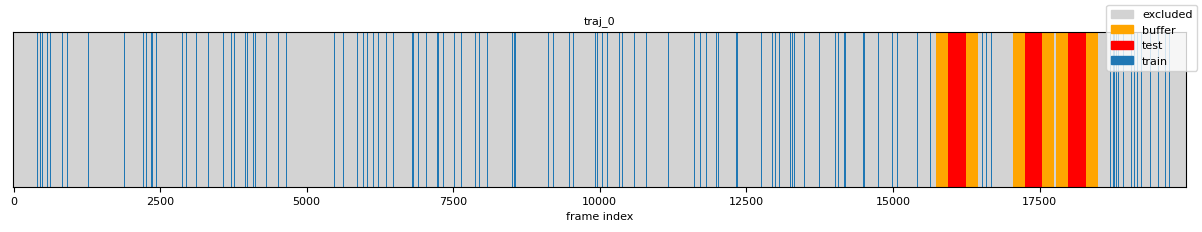

In [ ]:
train_frames, test_frames, conv_info, split_indices = load_trajectories(
    [frames_nvt_300],
    train_region='all',
    start_frames=conv_frames[0],
    test_n_blocks=3,
    test_block_length=300,
    test_buffer=buffers[0],
    train_fraction=0.1,
    seed=58,
    plot_splits=True,
)

In [ ]:
# save ALL results (also datasetS) to drive??:

import shutil
shutil.copytree("convergence_check/",
                "/content/drive/MyDrive/datasets_for_mace/convergence_check/",
                dirs_exist_ok=True)
print("Copied to Drive.")

Copied to Drive.


In [ ]:
# how to split train vs test: 2 separate FILES; test consists of individual strided/ buffered frames, shuffled; train consists of whatever we want (merged trajectories, where we made sure that frames around test frames were removed, not shuffled, with an indication of what frames were used.)

In [ ]:
# TODO(?): MACE testing to do: full, converged only, subsampled(? also check if no shuffle there), only with highest difference (on SMALL pctg of dataset)?